# Maximum common substructure

## Aim
In the previous notebook, we learned how to group molecules (clustering) and found that the molecules in one cluster look similar to each other and share a common scaffold. Besides visual inspection, we will learn here how to calculate the maximum substructure that a set of molecules has in common.

## For more details 
https://github.com/volkamerlab/teachopencadd/blob/master/teachopencadd/talktorials/T006_compound_maximum_common_substructures/talktorial.ipynb

## Instructions
Replace XXX with the appropriate code


## Configuration

In [1]:
# Magic commands
%load_ext autoreload
%autoreload 2

In [2]:
# Imports
# 1. Standard library imports
from copy import deepcopy
from pathlib import Path
import sys
sys.path.append('../my_modules') # to tell where to find local modules

# 2. Third-party library imports
from rdkit import Chem, Geometry
from rdkit.Chem import (
    AllChem,
    Draw,
    rdFMCS
)

# 3. Local application imports
import kernel_infos

In [3]:
# Information about the kernel
kernel_infos.show_kernel_info()

=== Kernel Information ===
Python version: 3.14.0 (main, Oct  7 2025, 09:34:52) [Clang 17.0.0 (clang-1700.0.13.3)]
Executable: /Users/bourg/Enseignement/GSON/gson_sbc/.venv/bin/python
Platform: macOS-26.2-arm64-arm-64bit-Mach-O
IPython version: 9.7.0


In [4]:
# Global variables
HERE = Path().resolve()
print(f'{HERE}')
ROOT = HERE.parent
print(f'{ROOT}')
DATA = ROOT / 'data'
print(f'{DATA}')

/Users/bourg/Enseignement/GSON/gson_sbc/notebooks
/Users/bourg/Enseignement/GSON/gson_sbc
/Users/bourg/Enseignement/GSON/gson_sbc/data


## Data

In [5]:
cluster_sdf_path = DATA / "cluster0.sdf"

In [6]:
# Load data with a RDKit supplier ForwardSDMolSupplier
supplier = Chem.ForwardSDMolSupplier(cluster_sdf_path)
# Stock molecules in a list mols_l
mols_l = list(supplier)

Number of loaded molecules: 357


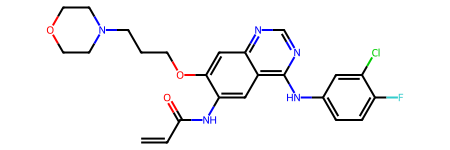

In [7]:
# Check
print(f"Number of loaded molecules: {len(mols_l)}")
mols_l[0]

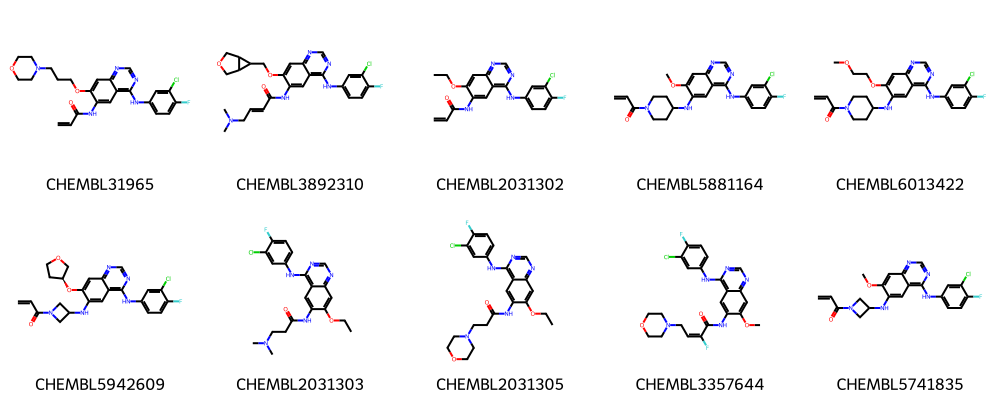

In [8]:
# Draw an image with the first 10 molecules (use slicing), 5 compounds per row, and add the _Name property in the legend
nb_mols = 10
Draw.MolsToGridImage(
    mols_l[:nb_mols],
    legends = [mol.GetProp('_Name') for mol in mols_l[:nb_mols]],
    molsPerRow=5
)

## Run FMCS algorithm with different input parameters

### Default parameters

In [9]:
# Find a mcs1 Maximum Common Substructure of mols_l with a method of rdFMCS
# Search the right method in rdFMCS
dir(rdFMCS)

['AtomCompare',
 'BondCompare',
 'FindMCS',
 'MCSAcceptance',
 'MCSAtomCompare',
 'MCSAtomCompareParameters',
 'MCSBondCompare',
 'MCSBondCompareParameters',
 'MCSFinalMatchCheck',
 'MCSParameters',
 'MCSProgress',
 'MCSProgressData',
 'MCSResult',
 'RingCompare',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__']

In [10]:
# Apply the method
mcs1 = rdFMCS.FindMCS(mols_l)

In [11]:
dir(mcs1)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'canceled',
 'degenerateSmartsQueryMolDict',
 'numAtoms',
 'numBonds',
 'queryMol',
 'smartsString']

In [12]:
# Describe mcs1
# Number of atoms and bonds
print(f"Nb of atoms: {mcs1.numAtoms} and nb of bonds: {mcs1.numBonds}")
# mcs1 SMART string
print(f"SMART string: {mcs1.smartsString}")

Nb of atoms: 14 and nb of bonds: 13
SMART string: [#6]:[#6]:[#6]:[#6](:[#7]:[#6]):[#6]:[#6]-[#7]-[#6](:[#6]:[#6]:[#6]):[#6]


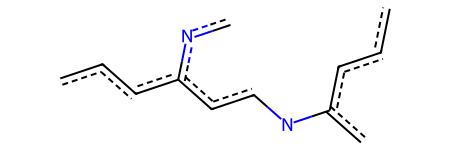

In [13]:
# Draw a structure from the smartString (similar to smiles transformation method)
mol1 = Chem.MolFromSmarts(mcs1.smartsString)
mol1

### Set a threshold

In [14]:
# Find a mcs2 Maximum Common Substructure of mols_l with a threshold of 0.8 (Please note that this may take a few minutes).
mcs2 = rdFMCS.FindMCS(mols_l, threshold=0.8)
print(f"MCS2 contains {mcs2.numAtoms} atoms and {mcs2.numBonds} bonds.")
print("SMARTS string:", mcs2.smartsString)

MCS2 contains 22 atoms and 24 bonds.
SMARTS string: [#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]2:[#6](-[#7]-[#6]3:[#6]:[#6]:[#6]:[#6]:[#6]:3):[#7]:[#6]:[#7]:[#6]:2:[#6]:[#6]:1-[#8]


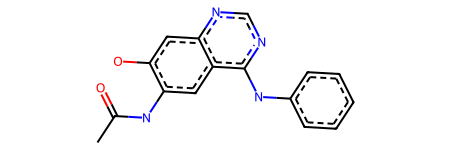

In [15]:
# Draw a structure from the smartString (similar to smiles transformation method)
mol2 = Chem.MolFromSmarts(mcs2.smartsString)
mol2

### Match ring bonds

In [16]:
# Find a mcs3 Maximum Common Substructure of mols_l with a threshold of 0.8, and add a match constraint regarding rings (Please note that this may take a few minutes).
mcs3 = rdFMCS.FindMCS(mols_l, threshold=0.8, ringMatchesRingOnly=True)
print(f"MCS3 contains {mcs3.numAtoms} atoms and {mcs3.numBonds} bonds.")
print("SMARTS string:", mcs3.smartsString)

MCS3 contains 19 atoms and 21 bonds.
SMARTS string: [#7&!R]-&!@[#6]1:&@[#6]:&@[#6]2:&@[#6](-&!@[#7&!R]-&!@[#6]3:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@3):&@[#7]:&@[#6]:&@[#7]:&@[#6]:&@2:&@[#6]:&@[#6]:&@1-&!@[#8&!R]


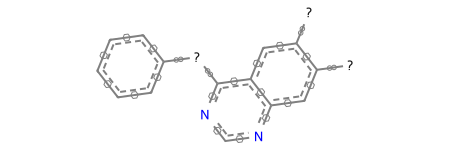

In [17]:
# Draw a structure from the smartString (similar to smiles transformation method)
mol3 = Chem.MolFromSmarts(mcs3.smartsString)
mol3

## Comparison

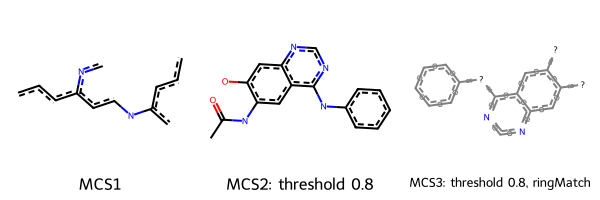

In [18]:
# Draw an image comparing the 3 previous obtained MCS
Draw.MolsToGridImage(
    [mol1, mol2, mol3],
    legends = ['MCS1', 'MCS2: threshold 0.8', 'MCS3: threshold 0.8, ringMatch']
)

## Define a helper to draw the molecules with the highlighted MCS: highlight_mcs()

Arguments

  - molecules to search for MCS: molecules
  - MCS to highlight: mcs
  - add or not '_Name' as legends via a boolean: label (True as default)
  - align molecules based on MCS via a boolean: same_orientation (True as default) 

In [19]:
def highlight_mcs(molecules, mcs, label=True, same_orientation=True):
    # copy molecules to avoid a permament highlighting
    molecules = deepcopy(molecules) 
    
    # convert MCS to a molecule
    pattern = Chem.MolFromSmarts(mcs.smartsString)
    
    # find the matching atoms (matching) in each molecule
    matching = [molecule.GetSubstructMatch(pattern) for molecule in molecules]
    
    # define legends
    legends = None
    if label:
        legends = [molecule.GetProp('_Name') for molecule in molecules]

    # Align molecules by matched substructure
    if same_orientation:
        mol, match = molecules[0], matching[0]
        AllChem.Compute2DCoords(mol)
        coords = [mol.GetConformer().GetAtomPosition(x) for x in match]
        coords2D = [Geometry.Point2D(pt.x, pt.y) for pt in coords]
        for mol, match in zip(molecules[1:], matching[1:]):
            if not match:
                continue
            coord_dict = {match[i]: coord for i, coord in enumerate(coords2D)}
            AllChem.Compute2DCoords(mol, coordMap=coord_dict)

    return Draw.MolsToGridImage(
        molecules,
        legends = legends,
        molsPerRow=5,
        highlightAtomLists=matching,
        subImgSize=(200,200),
    )
    


In [20]:
# Use ther helper function to highlight mcs1, mcs2 and mcs3 in the first 5 molecules of mols_l

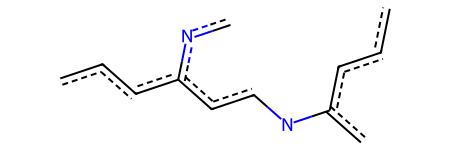

In [21]:
mol1

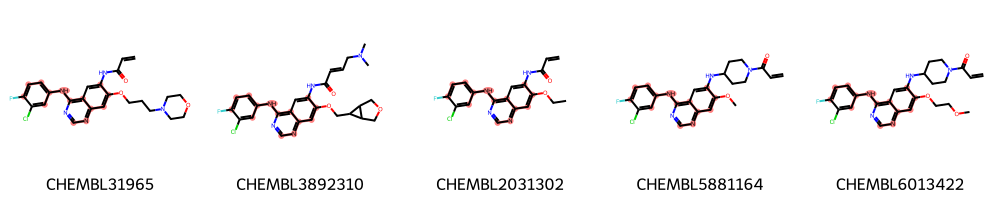

In [22]:
highlight_mcs(mols_l[:5], mcs1)

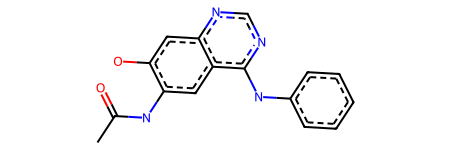

In [23]:
mol2

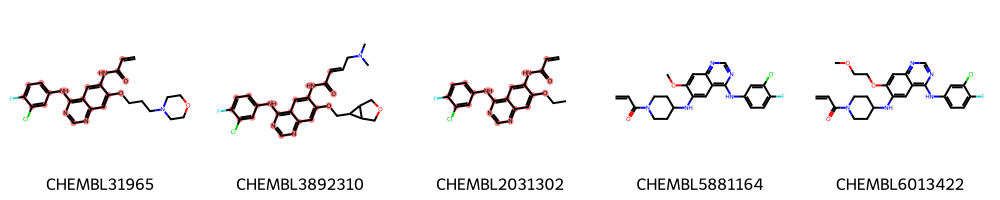

In [24]:
highlight_mcs(mols_l[:5], mcs2)

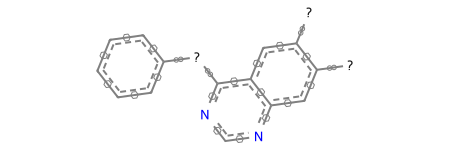

In [25]:
mol3

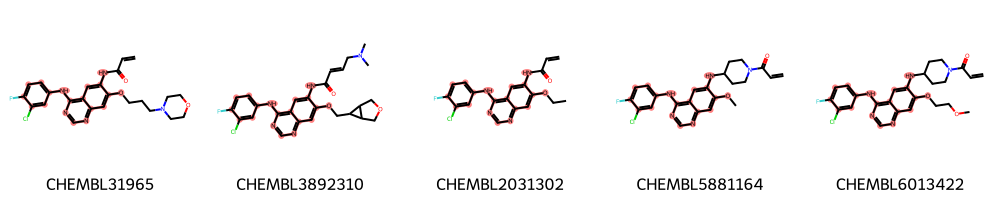

In [26]:
highlight_mcs(mols_l[:5], mcs3)